# 02 — Markov Chains
**Week 2 | Mathematical Foundations for RL**

Markov chains are the mathematical backbone of MDPs. The **Markov property** states:

$$P(s_{t+1} | s_t, s_{t-1}, ..., s_0) = P(s_{t+1} | s_t)$$

The future depends only on the present — not the history. This is what makes RL tractable.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
np.random.seed(0)

## 1. A Simple 3-State Markov Chain
States: Sunny (0), Cloudy (1), Rainy (2)

In [8]:
# Transition matrix T[i,j] = P(next=j | current=i)
T = np.array([
    [0.7, 0.2, 0.1],  # from Sunny
    [0.3, 0.4, 0.3],  # from Cloudy
    [0.2, 0.3, 0.5],  # from Rainy
])

state_names = ['Sunny', 'Cloudy', 'Rainy']

# Verify rows sum to 1
assert np.allclose(T.sum(axis=1), 1), "Rows must sum to 1!"
print("Transition matrix:")
print(T)

Transition matrix:
[[0.7 0.2 0.1]
 [0.3 0.4 0.3]
 [0.2 0.3 0.5]]


## 2. Simulate a Trajectory

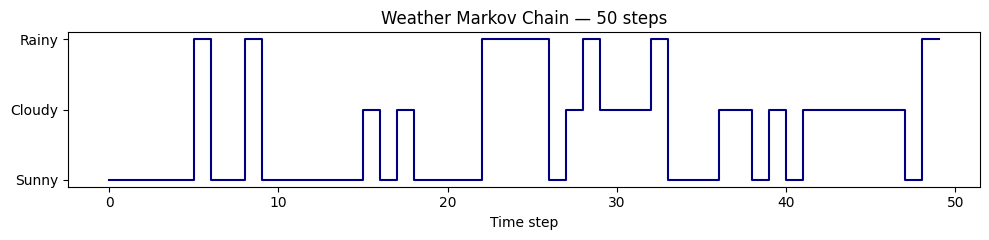

In [9]:
def simulate_markov(T, start_state, n_steps):
    trajectory = [start_state]
    state = start_state
    for _ in range(n_steps - 1):
        state = np.random.choice(len(T), p=T[state])
        trajectory.append(state)
    return np.array(trajectory)

traj = simulate_markov(T, start_state=0, n_steps=50)

plt.figure(figsize=(10, 2.5))
colors = ['gold', 'skyblue', 'steelblue']
plt.step(range(len(traj)), traj, where='post', color='navy', linewidth=1.5)
plt.yticks([0,1,2], state_names)
plt.xlabel('Time step'); plt.title('Weather Markov Chain — 50 steps')
plt.tight_layout(); plt.show()

## 3. Stationary Distribution
After many steps, the chain settles into a **stationary distribution** π where π = π · T.

We can find it as the left eigenvector of T corresponding to eigenvalue 1.

In [15]:
# Analytical: left eigenvector
eigenvalues, eigenvectors = np.linalg.eig(T.T)
idx = np.argmin(np.abs(eigenvalues - 1.0))  # eigenvalue closest to 1
stationary_analytical = np.real(eigenvectors[:, idx])
stationary_analytical /= stationary_analytical.sum()
print("Analytical stationary distribution:", np.round(stationary_analytical, 4))

# Empirical: simulate 100,000 steps
long_traj = simulate_markov(T, start_state=0, n_steps=100_000)
stationary_empirical = np.bincount(long_traj) / len(long_traj)
print("Empirical  stationary distribution:", np.round(stationary_empirical, 4))
     

Analytical stationary distribution: [0.4565 0.2826 0.2609]
Empirical  stationary distribution: [0.4649 0.2807 0.2544]


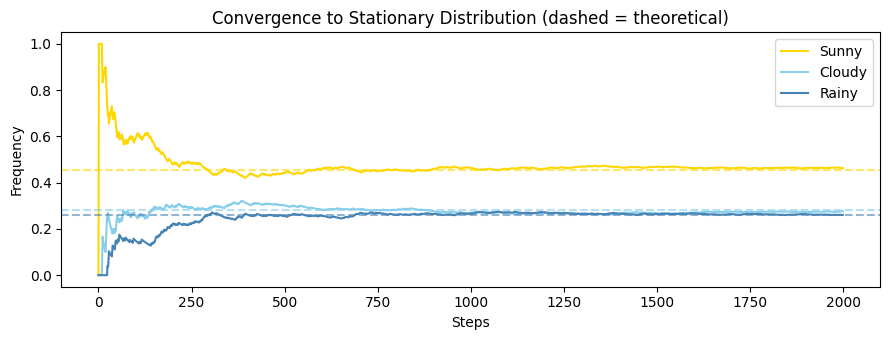

In [16]:
# Visualise convergence to stationary distribution
n_steps = 2000
state_freq = np.zeros((n_steps, 3))
traj_long = simulate_markov(T, start_state=0, n_steps=n_steps)
for t in range(1, n_steps):
    state_freq[t] = np.bincount(traj_long[:t+1], minlength=3) / (t+1)

fig, ax = plt.subplots(figsize=(9, 3.5))
colors_ = ['gold', 'skyblue', 'steelblue']
for i, (name, c) in enumerate(zip(state_names, colors_)):
    ax.plot(state_freq[:, i], color=c, linewidth=1.5, label=name)
    ax.axhline(stationary_analytical[i], color=c, linestyle='--', alpha=0.6)
ax.set_xlabel('Steps'); ax.set_ylabel('Frequency')
ax.set_title('Convergence to Stationary Distribution (dashed = theoretical)')
ax.legend(); plt.tight_layout(); plt.show()

## 4. Matrix Power — Another View
P(state at t=n | start state) = T^n · initial_distribution

In [6]:
init = np.array([1.0, 0.0, 0.0])  # start in Sunny
print(f"t=0:  {init}")
Tn = T.copy()
for t in [1, 5, 10, 50]:
    Tn_power = np.linalg.matrix_power(T, t)
    dist = init @ Tn_power
    print(f"t={t:<3}: {np.round(dist, 4)}")  # should converge to stationary

t=0:  [1. 0. 0.]


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 4 is different from 3)

## ✅ Exercises
1. Change the transition matrix so that once it rains, it always rains next (absorbing state). What happens to the stationary distribution?
   1. Ans - when we changed the rainy as absorbing state implies once the chain enters rainy it can never go back to cloudy or sunny as the probability keeps        leaking into rainy and never comes back .Over time the matrix collapses to [0,0,1] i.e it's always rainy. We can also refer to the visualisation added later in the notebook which shows the same .
2. Add a 4th state (Stormy) to the chain. Update T, make sure rows sum to 1, and re-run.

3. **Challenge**: prove to yourself that `π @ T == π` for the stationary distribution you computed above. Write the assertion.

## **Question 1**


**Ans –** When we changed Rainy into an absorbing state, it implies that once the chain enters Rainy, it can never go back to Cloudy or Sunny, as the probability keeps leaking into Rainy and never comes back. Over time, the distribution collapses to **[0, 0, 1]**, i.e., it's always Rainy. We can also refer to the visualisation added below in the notebook, which shows the same.

In [11]:
# Question 1
T_absorbing = np.array([
    [0.7, 0.2, 0.1],
    [0.3, 0.4, 0.3],
    [0.0, 0.0, 1.0],
])
assert np.allclose(T_absorbing.sum(axis=1), 1)

long_traj = simulate_markov(T_absorbing, start_state=0, n_steps=100_000)
stationary_empirical = np.bincount(long_traj, minlength=3) / len(long_traj)
print("Empirical stationary distribution:", np.round(stationary_empirical, 4))

Empirical stationary distribution: [0.     0.     0.9999]


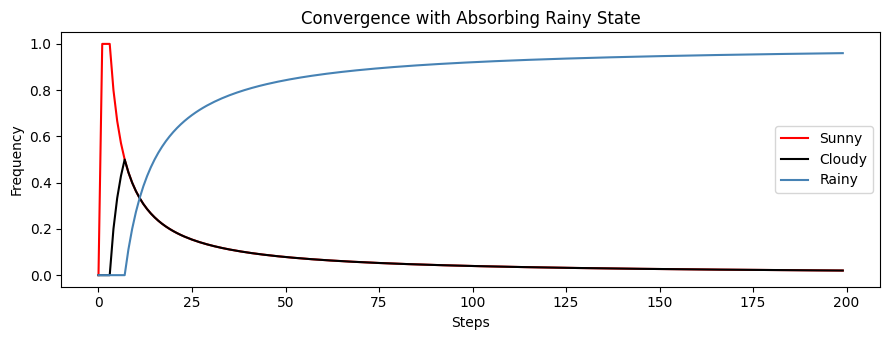

In [12]:
# Visualisation of change done as per question 1 .
n_steps = 200
state_freq_abs = np.zeros((n_steps, 3))
traj_abs = simulate_markov(T_absorbing, start_state=0, n_steps=n_steps)

for t in range(1, n_steps):
    state_freq_abs[t] = np.bincount(traj_abs[:t+1], minlength=3) / (t+1)

fig, ax = plt.subplots(figsize=(9, 3.5))
colors_ = ['Red', 'Black', 'steelblue']
for i, (name, c) in enumerate(zip(state_names, colors_)):
    ax.plot(state_freq_abs[:, i], color=c, linewidth=1.5, label=name)

ax.set_xlabel('Steps'); ax.set_ylabel('Frequency')
ax.set_title('Convergence with Absorbing Rainy State')
ax.legend(); plt.tight_layout(); plt.show()

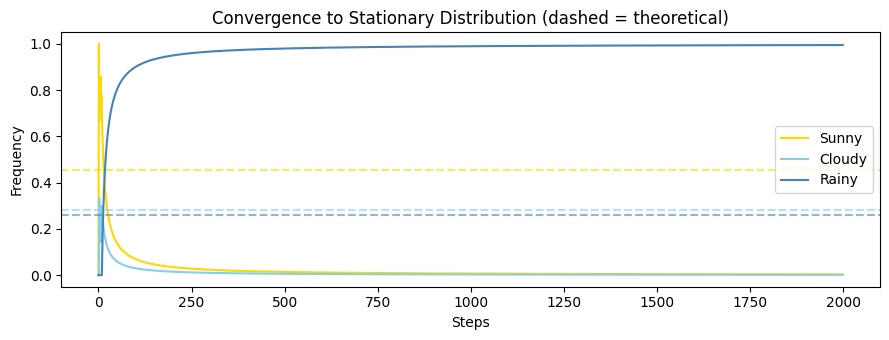

In [17]:
# Visualise convergence to stationary distribution
n_steps = 2000
state_freq = np.zeros((n_steps, 3))
traj_long = simulate_markov(T_absorbing, start_state=0, n_steps=n_steps)
for t in range(1, n_steps):
    state_freq[t] = np.bincount(traj_long[:t+1], minlength=3) / (t+1)

fig, ax = plt.subplots(figsize=(9, 3.5))
colors_ = ['gold', 'skyblue', 'steelblue']
for i, (name, c) in enumerate(zip(state_names, colors_)):
    ax.plot(state_freq[:, i], color=c, linewidth=1.5, label=name)
    ax.axhline(stationary_analytical[i], color=c, linestyle='--', alpha=0.6)
ax.set_xlabel('Steps'); ax.set_ylabel('Frequency')
ax.set_title('Convergence to Stationary Distribution (dashed = theoretical)')
ax.legend(); plt.tight_layout(); plt.show()

## Question 2.

In [7]:
# Transition matrix T[i,j] = P(next=j | current=i)
T = np.array([
    [0.60, 0.20, 0.10, 0.10],  # from Sunny
    [0.25, 0.35, 0.25, 0.15],  # from Cloudy
    [0.10, 0.20, 0.40, 0.30],  # from Rainy
    [0.05, 0.10, 0.35, 0.50],  # from Stormy 
])

state_names = ['Sunny', 'Cloudy', 'Rainy', 'Stormy']

# Verify rows sum to 1
assert np.allclose(T.sum(axis=1), 1), "Rows must sum to 1!"
print("Transition matrix:")
print(T)

Transition matrix:
[[0.6  0.2  0.1  0.1 ]
 [0.25 0.35 0.25 0.15]
 [0.1  0.2  0.4  0.3 ]
 [0.05 0.1  0.35 0.5 ]]


## **Question 3**

In [ ]:
# Question 3 (Challenge)
pi = stationary_analytical
result = pi @ T
 
print("π @ T =", np.round(result, 6))
print("π      =", np.round(pi, 6))

assert np.allclose(pi @ T, pi), "Stationary distribution check failed!"
print("Hence Proved: π @ T == π")